Ten notebook jest kontynuacją [zadania architektury CNN dla segmentacji zdjęcia](https://github.com/Solvro/ml-wakacyjne-wyzwanie-2026/blob/sz3kz-dev/03_sieci_neuronowe_wizja_komputerowa/03_computer_vision_hw.ipynb)

# ENVIRONMENT SETUP
## Detekcja Środowiska Wykonawczego

In [ ]:
def is_execution_inside_colab():
    try:
        import google.colab
        return True
    except:
        return False

## Konfiguracja Specyficzna dla środowiska

In [ ]:
if is_execution_inside_colab():
    datasets_location = "./datasets"
else:
    datasets_location = "../../../datasets"

## Ogólny Setup Środowiska

In [ ]:
import os
# Ustawione przed pierwszym uzyciem CUDA - dla spojnosci srodowiska pomiarowego
# z notebookiem SNN (tam rozwiazywalo fragmentacje alokatora; tutaj glownie
# dla porownywalnosci warunkow pomiaru pamieci).
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import random
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from  torchvision import transforms
from torchvision.transforms import functional as TF
from torch.utils.data import random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True


device: cuda


# PARAMETER CONFIG

In [ ]:
CONFIG = {
    "data_root": datasets_location,

    # Zbiezne z notebookiem SNN (tam 64px po redukcji z powodu OOM).
    # UWAGA: swiadomie inny sensor/dataset (Caltech101 RGB vs N-Caltech101
    # zdarzenia) - to jest zamierzony punkt porownania "SNN+event camera vs
    # CNN+frame camera", nie proba upodobnienia samych danych wejsciowych.
    "image_size": 64,

    # Ten sam efektywny batch co SNN: batch_size * accum_steps = 16.
    "batch_size": 8,
    "accum_steps": 2,

    "num_workers": 2,
    # 100 klas obiektow - "Faces" usuniete, zeby zgadzac sie z N-Caltech101.
    # Klasa tla ("BACKGROUND_Google") jest w torchvision juz wykluczona
    # z indeksu probek, wiec po stronie SNN rowniez ja wykluczamy zamiast
    # probowac ja odtworzyc - patrz notebook SNN.
    "num_classes": 100,

    # Ten sam optymalizator co w notebooku SNN (Adam, ta sama lr i beta).
    # Funkcja straty MUSI pozostac inna (CrossEntropy vs mse_count_loss) -
    # SNN operuje na liczbie spike'ow, CNN na logitach, wiec nie da sie tego
    # zbiegowac bez zmiany zadania.
    "lr": 2e-3,

    "epochs": 5,
    "max_steps_per_epoch": None,
    "validation_split_size": 0.2,

    # Mixed precision - dla porownywalnosci pomiaru pamieci/czasu z SNN.
    "use_amp": True,
}

print(CONFIG)


{'data_root': './datasets', 'image_size': 64, 'batch_size': 8, 'accum_steps': 2, 'num_workers': 2, 'num_classes': 100, 'lr': 0.002, 'epochs': 5, 'max_steps_per_epoch': None, 'validation_split_size': 0.2, 'use_amp': True}


# Data Augmentation

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class AugmentedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

full_dataset = datasets.Caltech101(root=CONFIG["data_root"], download=True)

# WAZNE: torchvision.datasets.Caltech101 juz usuwa "BACKGROUND_Google" z listy
# klas i z indeksu probek (traktuje ja jako "not a real class"). Zostaje 101
# klas obiektow, w tym osobno "Faces" i "Faces_easy". N-Caltech101 usuwa
# "Faces" (zeby uniknac duplikatu z "Faces_easy"), ale ma za to klase tla -
# czyli oba zbiory maja liczebnie 101, ale to RUZNE zestawy etykiet.
#
# Zamiast probowac odtworzyc klase tla po tej stronie (torchvision juz
# wyrzucil jej probki z indeksu, wiec wymagaloby to przebudowy datasetu),
# usuwamy "Faces" tutaj i - symetrycznie - klase tla po stronie N-Caltech101
# (patrz notebook SNN). Efekt: czysty, wspolny problem 100-klasowy.
print("liczba klas w Caltech101 (torchvision), przed filtrowaniem:", len(full_dataset.categories))

FACES_LABEL = "Faces"
faces_idx = full_dataset.categories.index(FACES_LABEL)

# Indeksy probek NIE nalezacych do klasy "Faces"
keep_indices = [i for i, y in enumerate(full_dataset.y) if y != faces_idx]

# Mapowanie starych etykiet (z "dziura" po Faces) na nowe, ciagle 0..99
old_categories = full_dataset.categories
new_categories = [c for c in old_categories if c != FACES_LABEL]
label_remap = {old_categories.index(c): new_categories.index(c) for c in new_categories}


class FilteredCaltech101(Dataset):
    """Caltech101 bez klasy 'Faces', z etykietami przemapowanymi na 0..99."""

    def __init__(self, base, keep_indices, label_remap, categories):
        self.base = base
        self.keep_indices = keep_indices
        self.label_remap = label_remap
        self.categories = categories

    def __len__(self):
        return len(self.keep_indices)

    def __getitem__(self, idx):
        img, old_label = self.base[self.keep_indices[idx]]
        return img, self.label_remap[old_label]


full_dataset = FilteredCaltech101(full_dataset, keep_indices, label_remap, new_categories)

print("liczba klas po usunieciu 'Faces':", len(full_dataset.categories))
assert len(full_dataset.categories) == CONFIG["num_classes"], (
    "CONFIG num_classes nie zgadza sie z faktyczna liczba klas po filtrowaniu - "
    "sprawdz zgodnosc etykiet z N-Caltech101 przed porownaniem accuracy."
)

validation_dataset_size = int(len(full_dataset) * CONFIG["validation_split_size"])
training_dataset_size = len(full_dataset) - validation_dataset_size
training_dataset, validation_dataset = random_split(
    full_dataset,
    [training_dataset_size, validation_dataset_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Dodatkowo próbuję konwertować wszystkie zdjęcia na RGB jeśli można (nie wiem czy jest to robione automatycznie)
def ensure_rgb(img):
    return img.convert("RGB") if img.mode != "RGB" else img

# Augmentacje dla treningu
training_dataset_augmentations = transforms.Compose([
    transforms.Lambda(ensure_rgb),
    transforms.RandomResizedCrop(CONFIG["image_size"], scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Czyste transformacje
validation_dataset_augmentations = transforms.Compose([
    transforms.Lambda(ensure_rgb),
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

training_dataset = AugmentedDataset(training_dataset, transform=training_dataset_augmentations)
validation_dataset = AugmentedDataset(validation_dataset, transform=validation_dataset_augmentations)

# Loadery ładnie dzielą dataset na batche i przygotowywują do poprawnego trenowania współbieżnego
training_dataset_loader = DataLoader(
    training_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

validation_dataset_loader = DataLoader(
    validation_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

100%|██████████| 137M/137M [00:08<00:00, 16.3MB/s]


liczba klas w Caltech101 (torchvision), przed filtrowaniem: 101
liczba klas po usunieciu 'Faces': 100


### Podgląd danych wejściowych (VOC)

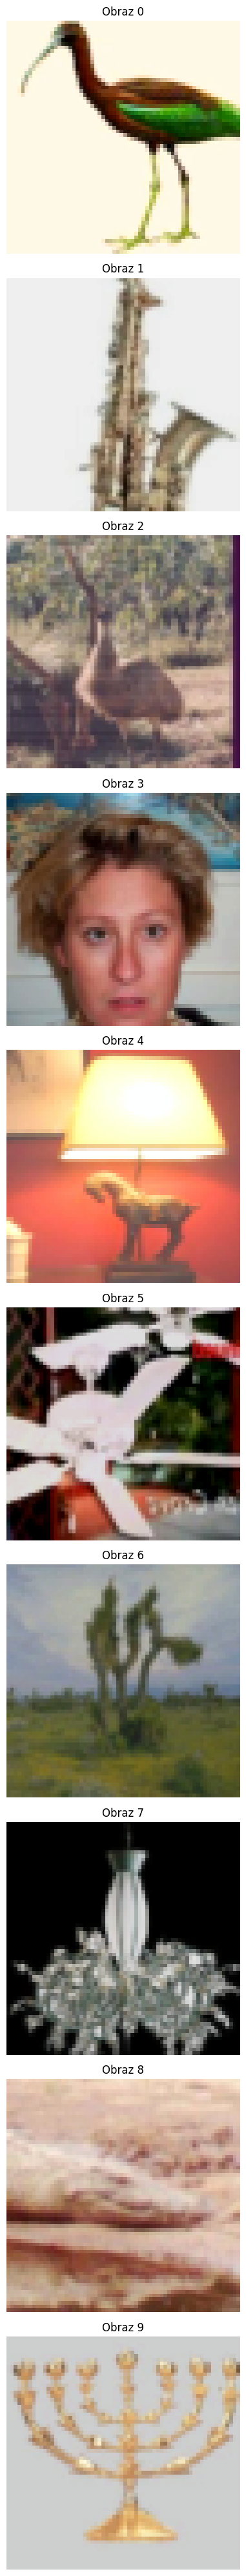

In [ ]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i].imshow(img_display)
        axes[i].set_title(f"Obraz {i}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

visualize_input_samples(training_dataset, 10)

# Basic Block

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    '''
    Residual Block contains 2 conv layers followed by a batch norm
    '''
    def __init__(self, in_channels, out_channels, downsampling_layer=None, stride=1):
        super().__init__()

        # convolutional layers
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1, stride=stride, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1, stride=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()
        self.downsampling_layer = downsampling_layer

    def forward(self, x):
        '''
        forward pass
        '''
        res = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # downsample
        if self.downsampling_layer is not None:
            res = self.downsampling_layer(res)

        out += res
        out = self.relu(out)

        return out

# Konstrukcja Sieci

In [ ]:
import torch

class SmallResNet(nn.Module):
    '''
    Residual Network
    '''
    def __init__(self, num_layers, img_channels, num_classes, use_final=True):
        super().__init__()
        self.expansion = 1
        self.use_final = use_final
        self.in_channels = 64 # starting input size fo residual blocks
                              # This value will increase by the factor of 1

        ### INPUT BLOCK:
        # the input block contains a convolutional block with the output size of 64.
        # the kernel size for this conv layer is set to 7 (7x7 kernel) with a stride of one
        # which mean no downsampling
        self.conv1 = nn.Conv2d(img_channels,
                               64,
                               kernel_size=7,
                               # PAMIEC/ARCHITEKTURA: stride=2, padding=3 - zgodne
                               # ze standardowym ResNet-18 i z poprawiona wersja
                               # conv1 w notebooku SNN (tam stride=1 bez paddingu
                               # bylo bledem powodujacym 4x wieksze mapy cech).
                               stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.relu = nn.ReLU()
        ### RESIDUAL LAYERS:
        # In the resnet paper, there are 4 residual layers,
        # but for each layer, the number of ResBlocks is different (based on the model variant needed)
        self.layer1 = self._layer(BasicBlock, num_layers[0], stride=1, out_channels=64)
        self.layer2 = self._layer(BasicBlock, num_layers[1], stride=2, out_channels=128)
        self.layer3 = self._layer(BasicBlock, num_layers[2], stride=2, out_channels=256)
        self.layer4 = self._layer(BasicBlock, num_layers[3], stride=2, out_channels=512)

        ### FINAL LAYERS:
        # if the user decided to use the final layer, it will be used based on the paper has a Linear layer with
        # 512 * expansion-rate units
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        if use_final:
            # the final layers
            self.fc = nn.Linear(512 * self.expansion, num_classes)

    def forward(self, x):
        '''
        forward pass
        '''
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.maxpool(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avg_pool(out)
        out = out.view(out.shape[0], -1)

        if self.use_final:
            out = self.fc(out)

        return out

    def _layer(self, block, num_layers, stride, out_channels):
        '''
        making a residual layer containing num_layers number of residual blocks.
        '''
        layers = []
        downsampling_layer = None # the downsampling will be filled if it matched the condition of:
            # the stride being greater than one or twe want to downsample for identity mapping
        if stride != 1 or self.in_channels != out_channels * 1:
            downsampling_layer = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels*self.expansion, kernel_size=1, stride=stride, padding=0),
                nn.BatchNorm2d(out_channels*self.expansion)
            )

        # add the block for downsampling
        layers.append(block(self.in_channels, out_channels, downsampling_layer, stride))
        self.in_channels = out_channels * self.expansion # updating for passing it to the next layer of the block

        # adding blocks
        for _ in range(num_layers - 1):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

def ResNet18(img_channels, num_classes, device='cuda', use_final=True):
    '''
    Using the architectures to build a resnet18 model
    '''
    # raising an error for not entering true parameters to the function
    if use_final and num_classes is None:
        raise Exception('when use_final is set to true, it is necessary to give an integer value to num_classes')

    # define the model under different conditions
    model = SmallResNet(
        num_layers=[2, 2, 2, 2],
        img_channels=img_channels,
        num_classes=num_classes if use_final else None,
        use_final=use_final
    ).to(device=device)

    return model

model = ResNet18(img_channels=3, num_classes=CONFIG["num_classes"], device=device)

n_params = sum(p.numel() for p in model.parameters())
print(f"parametry: {n_params/1e6:.2f} M")

parametry: 11.23 M


In [ ]:
import time

criterion = nn.CrossEntropyLoss()
# Ten sam typ optymalizatora, lr i beta co w notebooku SNN.
# (weight_decay z pierwotnej wersji usuniety, zeby konfiguracja optymalizacyjna
# byla scisle zbiezna - dopisz z powrotem, jesli zalezy Ci bardziej na
# accuracy CNN niz na porownywalnosci hiperparametrow miedzy modelami).
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], betas=(0.9, 0.999))

scaler = torch.amp.GradScaler('cuda', enabled=CONFIG["use_amp"])
accum_steps = CONFIG["accum_steps"]


def classification_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


train_loss_hist = []
val_loss_hist = []
val_acc_hist = []

torch.cuda.reset_peak_memory_stats()
t_start = time.time()

best_val_acc = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    running_loss = 0.0
    n_batches = 0

    for i, (imgs, labels) in enumerate(training_dataset_loader):
        if CONFIG["max_steps_per_epoch"] is not None and i >= CONFIG["max_steps_per_epoch"]:
            break

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            logits = model(imgs)
            loss = criterion(logits, labels)

        # Akumulacja gradientu - efektywny batch = batch_size * accum_steps,
        # jak w notebooku SNN.
        scaler.scale(loss / accum_steps).backward()

        if (i + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item()
        n_batches += 1

        del imgs, labels, logits, loss

        if i % 25 == 0:
            print(f"Epoch {epoch}, Iteration {i} | Train Loss: {running_loss / n_batches:.3f} "
                  f"| peak GPU: {torch.cuda.max_memory_allocated()/2**30:.2f} GiB")

    if n_batches % accum_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    train_loss_hist.append(running_loss / max(n_batches, 1))

    # --- ewaluacja ---------------------------------------------------------
    model.eval()
    val_loss_total = 0.0
    val_accs = []

    with torch.no_grad():
        for imgs, labels in validation_dataset_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
                logits = model(imgs)
                loss = criterion(logits, labels)

            val_loss_total += loss.item()
            val_accs.append(classification_accuracy(logits, labels))

            del imgs, labels, logits, loss

    avg_val_loss = val_loss_total / len(validation_dataset_loader)
    avg_val_acc = float(np.mean(val_accs))

    val_loss_hist.append(avg_val_loss)
    val_acc_hist.append(avg_val_acc)
    best_val_acc = max(best_val_acc, avg_val_acc)

    print(f"--- Epoch {epoch} | Train Loss: {train_loss_hist[-1]:.3f} "
          f"| Val Loss: {avg_val_loss:.3f} | Val Acc: {avg_val_acc:.3f}")

elapsed = time.time() - t_start
print(f"\nCzas treningu: {elapsed/60:.1f} min")
print(f"Szczytowe zuzycie pamieci GPU: {torch.cuda.max_memory_allocated()/2**30:.2f} GiB")
print("Best Val Accuracy:", best_val_acc)


Epoch 0, Iteration 0 | Train Loss: 4.925 | peak GPU: 0.65 GiB
Epoch 0, Iteration 25 | Train Loss: 5.046 | peak GPU: 0.65 GiB
Epoch 0, Iteration 50 | Train Loss: 4.878 | peak GPU: 0.65 GiB
Epoch 0, Iteration 75 | Train Loss: 4.649 | peak GPU: 0.65 GiB
Epoch 0, Iteration 100 | Train Loss: 4.510 | peak GPU: 0.65 GiB
Epoch 0, Iteration 125 | Train Loss: 4.362 | peak GPU: 0.65 GiB
Epoch 0, Iteration 150 | Train Loss: 4.336 | peak GPU: 0.65 GiB
Epoch 0, Iteration 175 | Train Loss: 4.282 | peak GPU: 0.65 GiB
Epoch 0, Iteration 200 | Train Loss: 4.236 | peak GPU: 0.65 GiB
Epoch 0, Iteration 225 | Train Loss: 4.188 | peak GPU: 0.65 GiB
Epoch 0, Iteration 250 | Train Loss: 4.190 | peak GPU: 0.65 GiB
Epoch 0, Iteration 275 | Train Loss: 4.157 | peak GPU: 0.65 GiB
Epoch 0, Iteration 300 | Train Loss: 4.130 | peak GPU: 0.65 GiB
Epoch 0, Iteration 325 | Train Loss: 4.117 | peak GPU: 0.65 GiB
Epoch 0, Iteration 350 | Train Loss: 4.088 | peak GPU: 0.65 GiB
Epoch 0, Iteration 375 | Train Loss: 4.056 | 

### Wizualizacja wyników treningu

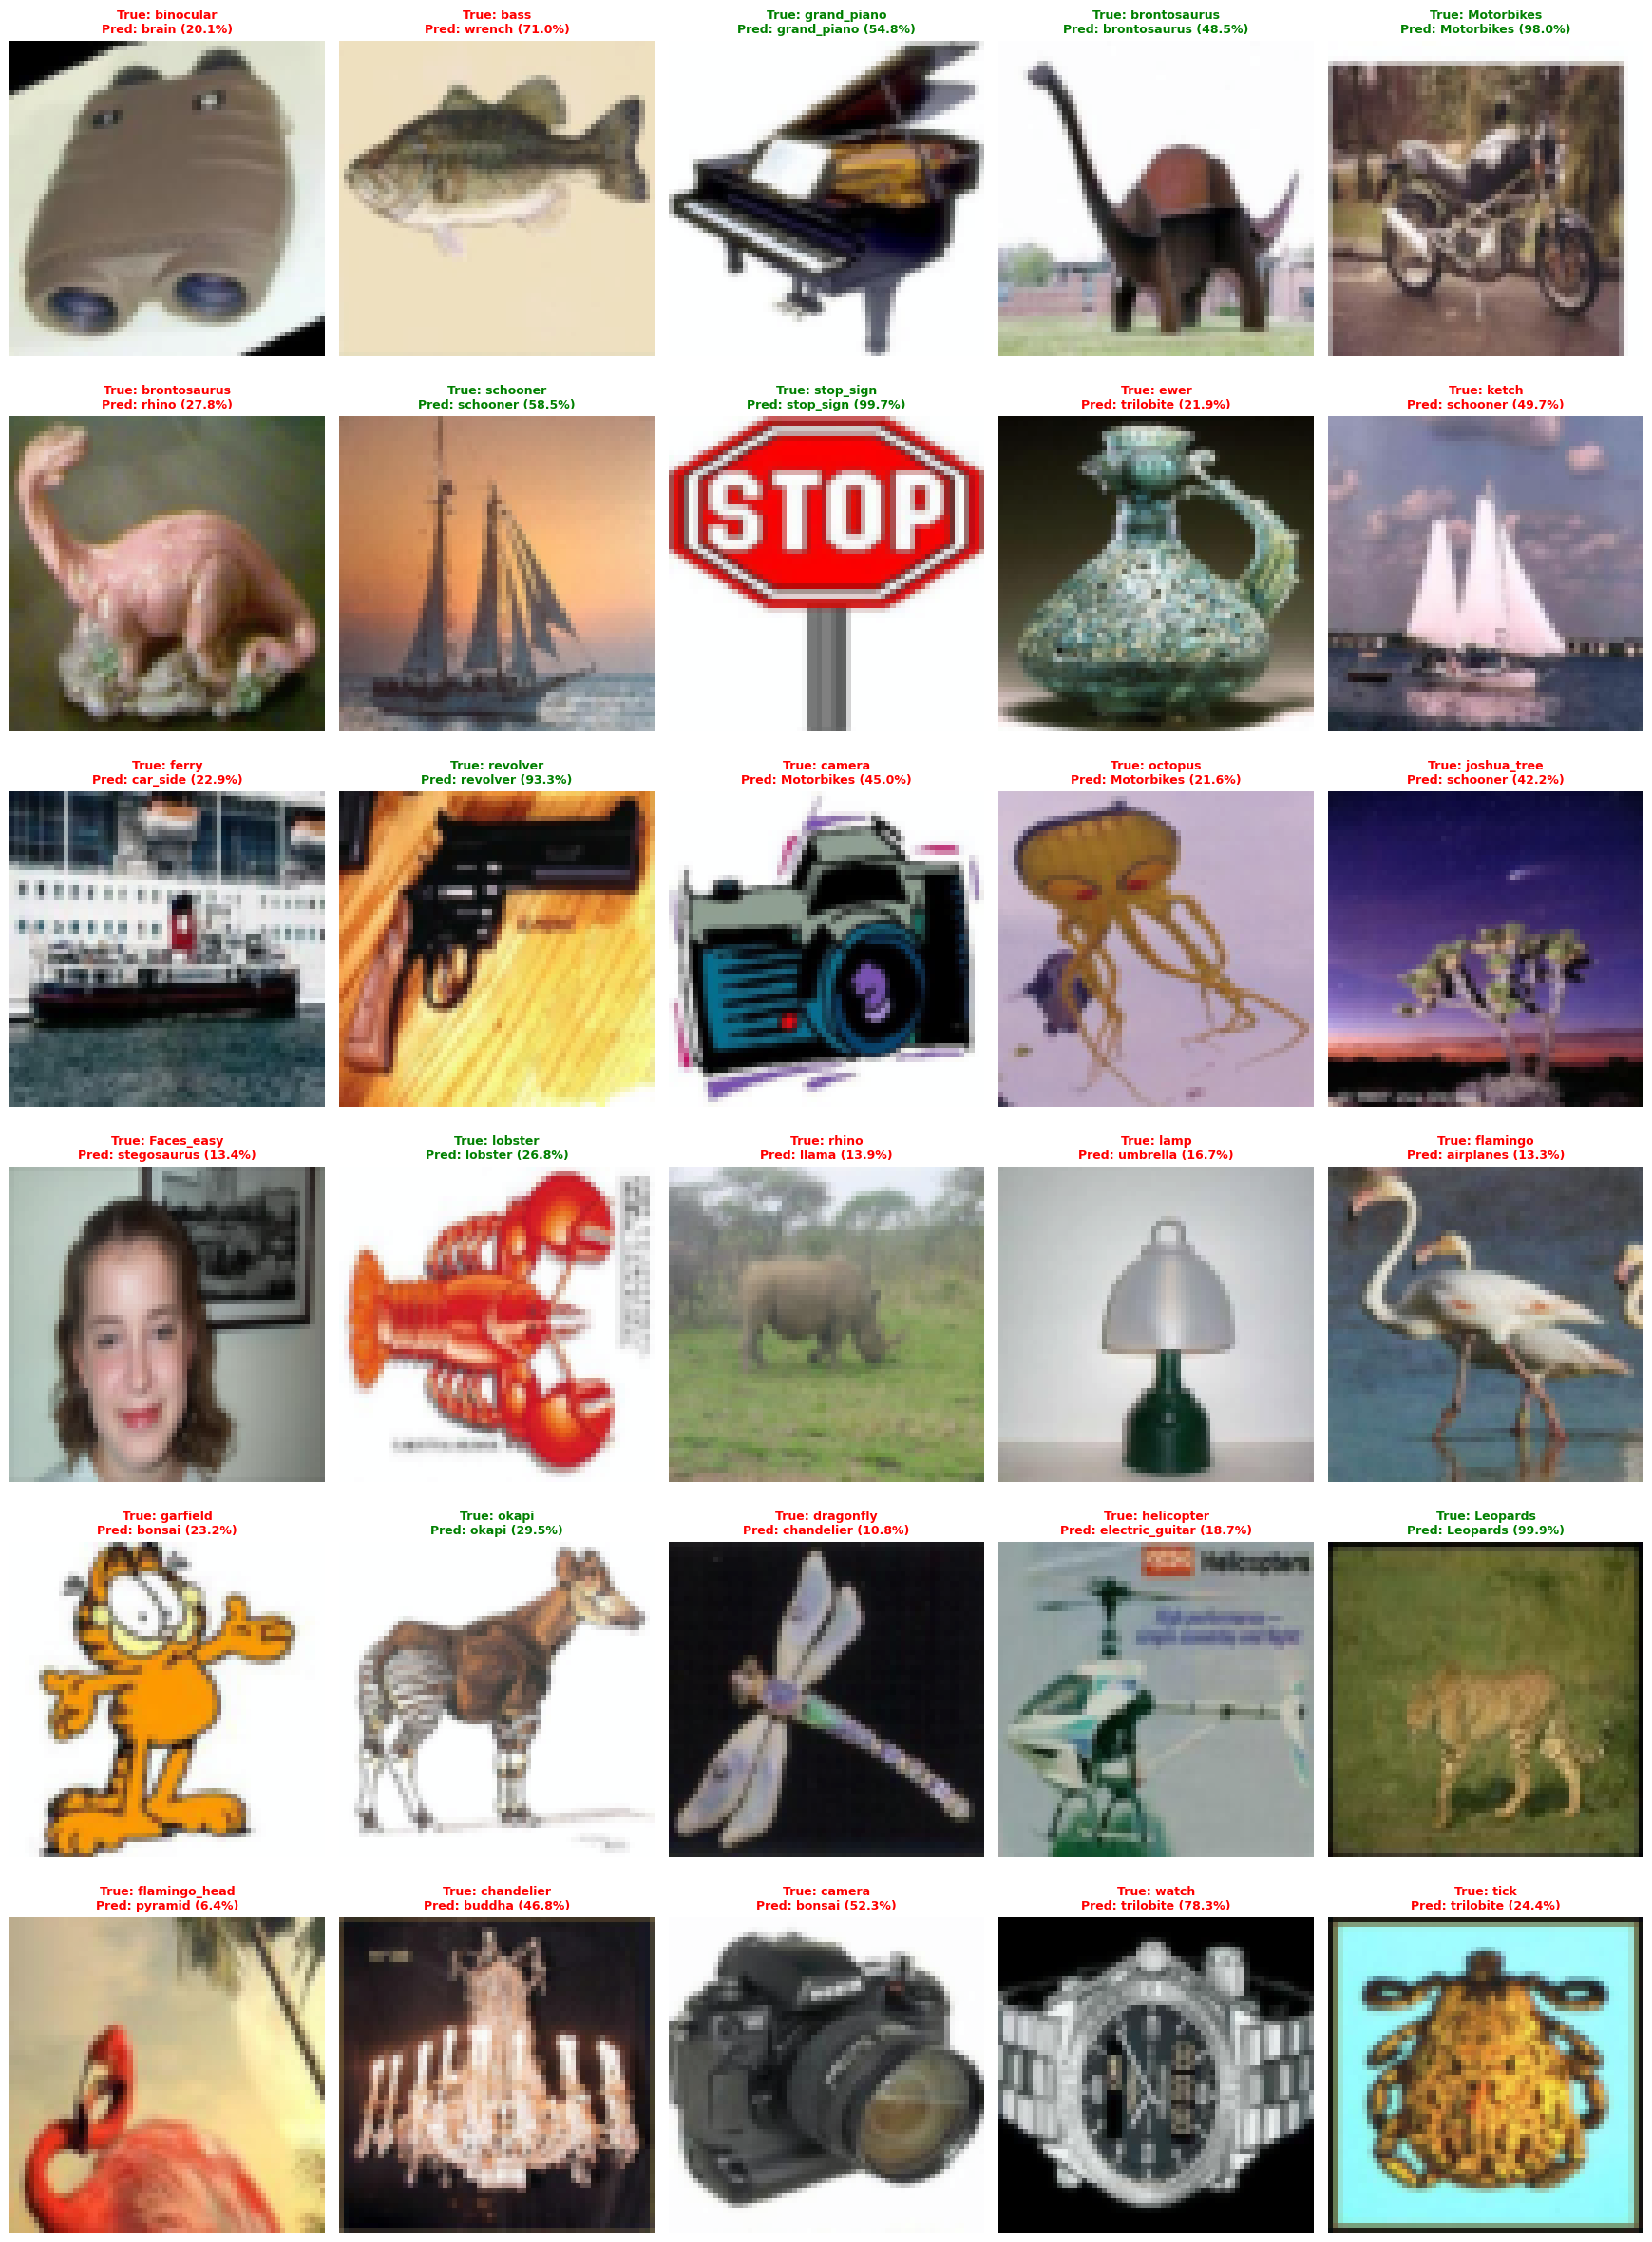

In [ ]:

def visualize_classification_predictions(model, dataset, categories, device, num_samples=10, cols=5):
    model.eval()

    # Wybieramy losowe indeksy ze zbioru walidacyjnego
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

    rows = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 4))
    axes = np.array(axes).flatten()

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # Przygotowanie batcha i predykcja
            input_tensor = img.unsqueeze(0).to(device)
            logits = model(input_tensor)
            probs = torch.softmax(logits, dim=1)
            pred_prob, pred_label = torch.max(probs, dim=1)

            pred_label = pred_label.item()
            pred_prob = pred_prob.item() * 100

            # Denormalizacja obrazu do [0, 1] dla matplotlib
            img_display = img.permute(1, 2, 0).cpu().numpy()
            img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            # Etykiety tekstowe
            true_name = categories[true_label]
            pred_name = categories[pred_label]

            # Rysowanie obrazu
            ax = axes[i]
            ax.imshow(img_display)
            ax.axis('off')

            # Kolor nagłówka: zielony (poprawna predykcja) / czerwony (błąd)
            color = 'green' if true_label == pred_label else 'red'
            title_text = f"True: {true_name}\nPred: {pred_name} ({pred_prob:.1f}%)"
            ax.set_title(title_text, color=color, fontsize=9, fontweight='bold')

        # Wyłączenie nieużywanych sub-plotów
        for j in range(len(indices), len(axes)):
            axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Wywołanie (pobieramy nazwy klas z obiektu full_dataset):
categories = full_dataset.categories
visualize_classification_predictions(model, validation_dataset, categories, device, num_samples=30)